# Brainstorm session 2026-09-11 — independent validation (AUDIT, N_TRIALS = 1)

Pre-registration: [README.md](README.md) (written before any run). Write-up: [findings.md](findings.md).

Five decision-bearing claims from `studies/material/brainstorming_session_sep11_2026/` are
(1) reproduced on the brainstorm's own cached data with an exact port of its statistics,
(2) re-derived from p300's database with an independent implementation, and (3) pushed through
data the original never saw and through p300's deflation / bootstrap bar.

| id | claim |
|---|---|
| C1 | big-bar daily momentum (+193.5 bp, t 3.04; "beats buy-and-hold") |
| C2 | funding-carry quartile timing (+7.7 % vs +3.4 %/yr) |
| C3 | absorption 5 m / 2 h (+4.8 bp, t 2.91) |
| C4 | ADX regime-machine claims (veto = stop-fill artefact; ±0.15 Sharpe bar-phase noise; short leg) |
| C5 | residual TA cells (Bollinger squeeze-down short; RSI enter-overbought long) |

Re-run order (each cell re-runs the script; all read-only against prod.db):
`run_c0_data_parity.py` → `run_c1_momentum.py` → `run_c2_carry_timing.py` → `run_c3_absorption.py`
→ `run_c4_adx_engine.py` → `run_c5_ta_residuals.py`. The last cells render `results/`.


## C0 — data parity gate

In [1]:
%run run_c0_data_parity.py

1. BTC daily: cache 3200 rows, p300 3311 rows, overlap 3199 | close max rel diff 6.88e-04 | volume p99 5.24e-04


2. BTC 5m cache -> 15m vs cd_spot_15m: overlap 112991 | close max 8.63e-03 | volume share>1% 0.0001 | taker share>1% 0.0001
3. funding: fetch 7676 prints 2019-09-10..2026-09-11 | pickle common 7673 max diff 0.0 | prod post-cutover equal-share 1.000 | prod PRE-cutover 08h rows equal-share 1.000 corr 1.00 | bybit corr 0.67
4. Bitstamp: pickle 5504 rows (2011-08-18..2026-09-11) vs json 5372 rows, overlap 5372, close max rel diff 1.39e-02; 4h pickle 32202 rows


5. p300 daily (hourly) vs daily (btc_1m): overlap 2445, close max rel diff 0.00e+00


6. ETH daily 2445 rows (2020-01-01..2026-09-10); alt panel 64 assets (814..1100 days); 5m-from-5s 105120 bars (2025-06-08..2026-06-07)
GATE: {'btc_daily': True, 'btc_5m': True, 'funding': True, 'bitstamp': True, 'p300_internal': True}


## C1 — big-bar daily momentum

In [2]:
%run run_c1_momentum.py

1. PARITY (their cache): {'n': 189, 'mean_bp': 193.53709642175843, 't': 3.0430225564664792, 'tc': 3.991401352903537, 'g': 20, 'win': 55.55555555555556, 'capture': 21.437906297376202, 'raw_mean_bp': 187.48070474627025, 'n_long': 87, 'long_mean_bp': 235.95339966118897, 'n_short': 102, 'short_mean_bp': 157.35848483518544} | expected {'n': 189, 'mean_bp': 193.5, 't': 3.04, 'tc': 3.99, 'win': 55.6, 'capture': 21.4} | PASS


2. p300 BTC daily: {'n': 197, 'mean_bp': 148.96411701609546, 't': 2.1497920901363186, 'tc': 2.6783361491829925, 'g': 20, 'win': 56.34517766497462, 'capture': 16.071093951645345, 'raw_mean_bp': 138.63925730014384, 'n_long': 89, 'long_mean_bp': 207.00353448655247, 'n_short': 108, 'short_mean_bp': 101.13533780433002} | truncation True
   per year:
  year  n     mean_bp         t       win
 2017  6 -856.677936 -0.898523 50.000000
 2018 21  149.261670  0.615769 61.904762
 2019 20   22.124540  0.118345 55.000000
 2020 20  239.468340  0.879229 55.000000
 2021 22  523.499556  2.572113 77.272727
 2022 18  314.884531  1.957796 66.666667
 2023 26  196.072809  1.352047 57.692308
 2024 26   59.598406  0.321477 46.153846
 2025 26  -94.448627 -0.979619 34.615385
 2026 12  395.245574  1.421877 66.666667
   era: {'pre_etf': {'n': 135, 'mean_bp': 176.21429575109565, 't': 1.959580379511044, 'win': 60.74074074074074}, 'post_etf': {'n': 62, 'mean_bp': 89.6290504156918, 't': 0.8850024246073901, 'win': 46.77

4. ETH spot daily: {'n': 146, 'mean_bp': 101.54875173006532, 't': 1.0928927095798935, 'tc': 1.209945443264616, 'g': 13, 'win': 52.73972602739726, 'capture': 9.048615451427311, 'raw_mean_bp': 73.50444827325515, 'n_long': 59, 'long_mean_bp': 35.58888288002283, 'n_short': 87, 'short_mean_bp': 146.28015704216313} 
   ETH perp daily: {'n': 123, 'mean_bp': 135.94953851223903, 't': 1.5487824114503355, 'tc': 3.044821806546063, 'g': 9, 'win': 52.84552845528455, 'capture': 12.659122785216207, 'raw_mean_bp': 118.41905369861402, 'n_long': 49, 'long_mean_bp': 50.65627631371358, 'n_short': 74, 'short_mean_bp': 192.4275094274789}
   alt panel pooled: {'n': 3503, 'n_assets': 64, 'mean_bp': 67.57741960381409, 't_naive': 2.3776765571031864, 't_week_cluster': 0.983249138371222, 'g_weeks': 148, 't_asset_cluster': 2.2472731778036756, 'g_assets': 64, 'share_assets_positive': 0.65625, 'win': 51.27033970882101}
5. grid: 60 cells, share t>2 = 0.22, share positive = 0.95, primary rank by t = 10/60
H          3 

7. sizing [their_cache] B&H final 48,960 CAGR 19.9% maxDD -83.2%
   frac1.0_maker_fund1x         final     50,499 CAGR   20.3% maxDD  -63.0% trades 345 gross mean 0.75x (in-mkt 1.56x, max 4.63x) TiM 0.48
   frac1.0_taker_fund1x         final     41,128 CAGR   17.5% maxDD  -64.9% trades 345 gross mean 0.75x (in-mkt 1.56x, max 4.63x) TiM 0.48
   frac0.5_maker_fund1x         final     28,148 CAGR   12.5% maxDD  -37.0% trades 345 gross mean 0.38x (in-mkt 0.78x, max 1.83x) TiM 0.48
   frac1.0_maker_fund3x         final     33,528 CAGR   14.8% maxDD  -66.7% trades 345 gross mean 0.75x (in-mkt 1.56x, max 4.64x) TiM 0.48
   frac1.0_taker_fund3x         final     27,294 CAGR   12.1% maxDD  -68.4% trades 345 gross mean 0.75x (in-mkt 1.56x, max 4.65x) TiM 0.48


7. sizing [p300] B&H final 186,373 CAGR 38.1% maxDD -83.2%
   frac1.0_maker_fund1x         final     24,107 CAGR   10.2% maxDD  -63.0% trades 363 gross mean 0.77x (in-mkt 1.58x, max 6.99x) TiM 0.49
   frac1.0_taker_fund1x         final     19,385 CAGR    7.6% maxDD  -64.9% trades 363 gross mean 0.77x (in-mkt 1.59x, max 7.00x) TiM 0.49
   frac0.5_maker_fund1x         final     23,299 CAGR    9.8% maxDD  -37.0% trades 363 gross mean 0.38x (in-mkt 0.79x, max 2.10x) TiM 0.49
   frac1.0_maker_fund3x         final     15,594 CAGR    5.0% maxDD  -66.7% trades 363 gross mean 0.77x (in-mkt 1.59x, max 7.02x) TiM 0.49
   frac1.0_taker_fund3x         final     12,534 CAGR    2.5% maxDD  -68.4% trades 363 gross mean 0.77x (in-mkt 1.59x, max 7.04x) TiM 0.49
8. DECISION: {'parity': True, 'unseen': {'bitstamp_2012_2017': False, 'eth_spot': False, 'alts_week_clustered': False}, 'n_unseen_pass': 0, 'dsr348': 0.21916357295787653, 'dsr_pass': False, 'beats_hold_exposure_matched_ci_above_0': False, 'verdic

## C2 — funding-carry quartile timing

In [3]:
%run run_c2_carry_timing.py

series: 7676 prints 2019-09-10..2026-09-11 | mean 0.0106%/8h | positive 85.7% | untimed 11.58%/yr
1. PARITY last 1200: {'lag1': 0.666, 'mean_8h_pct': 0.003, 'share_positive': 0.781, 'ann_pct': 3.677} [-1.0, 3.1, 5.1, 7.5]
          last  500: {'lag1': 0.745, 'mean_8h_pct': 0.003, 'share_positive': 0.778, 'ann_pct': 3.539} [-2.0, 2.9, 5.4, 7.7]
2. autocorr by year:
  year    n  lag1  lag2  lag3  mean_8h_pct  ann_pct  share_positive
 2019  338 0.656 0.505 0.412        0.007    7.482           0.817
 2020 1098 0.688 0.609 0.534        0.016   17.193           0.857
 2021 1095 0.806 0.746 0.708        0.028   30.608           0.927
 2022 1095 0.611 0.370 0.271        0.004    4.165           0.779
 2023 1095 0.768 0.701 0.668        0.007    7.866           0.899
 2024 1098 0.822 0.766 0.754        0.011   11.924           0.916
 2025 1095 0.553 0.468 0.468        0.005    5.126           0.871
 2026  762 0.692 0.609 0.583        0.003    2.756           0.726 
   full: {'lag1': 0.797, 'la

4. bootstrap (block 90 prints) of net difference vs ALWAYS_ON, %/yr:
   UPPER_HALF               diff -17.75  CI90 [-20.08, -15.38]  P(>0) 0.000
   TOP_QUARTILE             diff -12.45  CI90 [-14.55, -10.38]  P(>0) 0.000
   HYSTERESIS_p60_p40       diff  -7.85  CI90 [ -9.43,  -6.33]  P(>0) 0.000
   UPPER_HALF_minhold21d    diff  -3.57  CI90 [ -3.98,  -3.15]  P(>0) 0.000
   S078_live_rule           diff  -0.85  CI90 [ -1.11,  -0.60]  P(>0) 0.000
5. DECISION: {'upper_half_beats_always_on_full_sample': False, 'years_won': 0, 'years_compared': 7, 'ci90_excludes_zero': True, 'ci90': [-20.076342322634215, -15.376741164655641], 'verdict': 'KILL'}


## C3 — absorption

In [4]:
%run run_c3_absorption.py

1. PARITY their cache, z>1.0 (their table: 1h +2.9/2.54, 2h +4.8/2.91(2.16), 3h +4.8/2.25, 4h +1.6/0.62, 8h +1.5, 16h -1.4):
hours    n  mean_bp     t    tc    g   win  capture  net4.1
   1h 1818     2.88  2.54  1.91 1187 53.08     5.70   -1.22
   2h 1620     4.79  2.91  2.16  822 56.05     6.70    0.69
   3h 1488     4.79  2.25  1.31  612 54.50     5.47    0.69
   4h 1395     1.58  0.62  0.69  462 53.76     1.56   -2.52
   6h 1224     2.15  0.68  0.52  283 53.10     1.74   -1.95
   8h 1104     1.50  0.39 -0.23  182 52.45     1.05   -2.60
  12h  946     4.99  0.93 -0.67   77 51.06     2.85    0.89
  16h  813    -1.41 -0.22 -0.05   40 50.55    -0.70   -5.51
   1d  654     2.39  0.26  0.15   11 51.07     0.96   -1.71
 1.5d  518     8.64  0.73   NaN    2 52.32     2.85    4.54
   2d  423   -21.12 -1.35   NaN    1 49.17    -6.02  -25.22
   PASS | z>1.5 2h: [{'n': 665, 'mean_bp': 5.48, 't': 2.06, 'tc': 1.92}]
   2h cell on their cache by year:
  year   n  mean_bp    t   win
 2023 145     3.

4. spot_15m (2019-09-08..2026-09-11, 245672 bars), z>1.0:
hours    n  mean_bp     t    tc    g   win  capture  n_long  long_mean_bp  n_short  short_mean_bp  net4.1
   1h 1336    -4.65 -2.08 -1.64 1150 50.82    -6.91     743         -5.51      593          -3.57   -8.75
   2h 1274     0.11  0.04 -0.49 1009 52.90     0.12     710          1.72      564          -1.90   -3.99
   3h 1230    -4.77 -1.18 -0.89  893 51.95    -4.10     682         -3.46      548          -6.40   -8.87
   4h 1188    -7.32 -1.63 -1.10  792 50.84    -5.44     655         -4.79      533         -10.43  -11.42
   6h 1139    -7.69 -1.52 -0.96  635 50.48    -4.67     627         -5.91      512          -9.87  -11.79
   8h 1079    -8.63 -1.47 -0.83  515 49.03    -4.54     593         -3.37      486         -15.04  -12.73
  16h  934    -4.51 -0.50 -1.72  239 50.54    -1.68     515         -8.47      419           0.36   -8.61
   1d  817    -5.43 -0.43 -0.62  125 49.82    -1.65     452          5.42      365         -18

4. perp_15m (2019-09-08..2026-09-11, 245771 bars), z>1.0:
hours   n  mean_bp     t    tc   g   win  capture  n_long  long_mean_bp  n_short  short_mean_bp  net4.1
   1h 378     1.98  0.63  0.27 347 55.82     2.94     207          1.21      171           2.90   -2.12
   2h 366     4.17  0.90  0.66 329 54.64     4.38     201          2.82      165           5.83    0.07
   3h 361     3.30  0.56  0.10 315 53.19     2.83     198         -1.84      163           9.54   -0.80
   4h 354     7.35  1.09  0.87 304 51.41     5.46     197          7.56      157           7.09    3.25
   6h 349     0.22  0.03  0.52 270 51.58     0.14     193         -4.16      156           5.65   -3.88
   8h 335    -7.91 -0.84 -0.24 253 54.33    -4.15     187        -16.86      148           3.39  -12.01
  16h 315     4.80  0.37  0.37 182 52.70     1.78     172         -9.62      143          22.15    0.70
   1d 299    20.52  1.22  0.55 141 55.85     6.22     163          8.82      136          34.53   16.42


4. eth_perp_15m (2021-01-01..2026-09-11, 199666 bars), z>1.0:
hours   n  mean_bp     t    tc   g   win  capture  n_long  long_mean_bp  n_short  short_mean_bp  net4.1
   1h 272    -3.88 -0.75 -0.50 261 50.74    -4.62     162         -1.40      110          -7.52   -7.98
   2h 269    -9.76 -1.36 -1.28 245 52.79    -8.23     159         -4.65      110         -17.15  -13.86
   3h 266   -12.81 -1.43 -1.46 232 48.87    -8.82     157         -6.12      109         -22.46  -16.91
   4h 263   -10.57 -1.05 -1.33 228 49.81    -6.30     156         -7.37      107         -15.23  -14.67
   6h 258   -11.32 -0.95 -1.18 214 49.61    -5.51     152         -4.90      106         -20.51  -15.42
   8h 251    -7.71 -0.53 -0.73 203 49.40    -3.25     149          3.94      102         -24.73  -11.81
  16h 234   -17.14 -0.77 -0.78 158 47.86    -5.11     137         -4.19       97         -35.43  -21.24
   1d 226    -4.05 -0.14  0.36 126 53.54    -0.98     129         12.00       97         -25.38   -8.15
5.

6. DECISION: {'spot15m_t': 0.03977713578291354, 'spot15m_mean_bp': 0.11393760883112451, 'years_positive': 3, 'years': 8, 'perp_same_sign': True, 'signal_confirmed': False, 'tradable': False, 'verdict': 'KILL'}


## C4 — ADX regime machine

In [5]:
%run run_c4_adx_engine.py

1. PARITY [study fill] S003: Sh/CAGR/maxDD got (np.float64(1.02), np.float64(40.9), np.float64(-58.8)) expected (1.02, 40.9, -58.8) n=41 PASS
1. PARITY [study fill] S005: Sh/CAGR/maxDD got (np.float64(1.05), np.float64(41.4), np.float64(-41.2)) expected (1.05, 41.4, -41.2) n=46 PASS


1. PARITY [live  fill] S003: Sh/CAGR/maxDD got (np.float64(1.08), np.float64(43.6), np.float64(-37.5)) expected (1.08, 43.6, -37.5) n=41 PASS


1. PARITY [live  fill] S005: Sh/CAGR/maxDD got (np.float64(1.01), np.float64(39.4), np.float64(-41.4)) expected (1.01, 39.4, -41.4) n=46 PASS
   B&H same span: CAGR 42.3% Sh 0.86 maxDD -83.4% | veto inverts under live fill: True


2a. their engine, 6 phases: Sharpe 0.85..1.16 (expected 0.85..1.16)
  close_hour  sharpe  cagr  maxdd  n
          0   1.052 0.418 -0.411 46
          4   1.061 0.435 -0.458 40
          8   1.046 0.466 -0.459 47
         12   1.163 0.530 -0.461 39
         16   1.066 0.436 -0.403 43
         20   0.853 0.312 -0.537 46


2c. Tier-1 / Tier-2 vs baseline across the 24 phases (paired):
 phase_hour  base_maxdd  t1_maxdd  t2_maxdd  base_mar  t1_mar  t2_mar  base_ret  t1_ret  t2_ret  base_mtm_dd  t1_mtm_dd  t2_mtm_dd  base_sharpe  t1_sharpe  t2_sharpe  n_base  n_t2
          0      -27.34    -23.70    -15.12      1.67    1.86    2.91   2536.64 2274.35 2274.43       -50.93     -43.65     -38.00         0.97       1.00       1.11      35    28
          1      -27.34    -19.46    -19.46      1.44    2.21    2.17   1699.93 2131.42 2040.50       -46.39     -41.39     -41.39         0.82       0.92       1.02      33    27
          2      -27.34    -22.12    -18.34      1.49    1.84    2.22   1844.09 1837.53 1840.38       -47.56     -42.07     -42.07         0.92       0.94       0.99      33    27
          3      -27.34    -23.55    -19.18      1.88    1.68    2.25   3560.69 1711.36 2166.18       -41.93     -41.01     -41.01         1.08       0.93       1.02      36    30
          4      -31.76    -27.77    

4. short leg (p300 machine): n=19 closed shorts, mean price +2.31%, funding +0.40%, total +2.71% (CI90 [-2.84, 2.48, 8.98]); longs n=15 mean +31.51%
  entry_dt    exit_dt  days  price_net_pct  funding_pct  total_pct reason  still_open
2018-03-19 2018-04-24    36         -10.10         0.00     -10.10     SL       False
2018-10-23 2018-11-02    10           1.72         0.00       1.72 ADX<20       False
2018-11-18 2019-01-02    45          31.75         0.00      31.75 ADX<20       False
2019-09-25 2019-10-26    31         -10.10         0.56      -9.54     SL       False
2019-11-23 2019-12-28    35          -0.16         0.19       0.03 ADX<20       False
2021-04-22 2021-04-30     8         -10.10         0.34      -9.76     SL       False
2021-05-15 2021-09-05   113         -10.10         2.20      -7.90     SL       False
2022-04-27 2022-07-26    90          45.73         1.26      46.99 ADX<20       False
2022-09-06 2022-09-09     3         -10.10         0.04     -10.06     SL    

## C5 — residual TA cells

In [6]:
%run run_c5_ta_residuals.py

squeeze H=24 on every candidate panel (quoted: n=46, +1008.4 bp, cluster t 4.19): {'spot_BTCUSDT_1d_3200d.pkl': {'n': 43, 'mean_bp': 454.5199549470448, 't': 1.8043595329889939, 'tc': 2.9544829850414662}, 'spot_BTCUSDT_1d_3300d.pkl': {'n': 45, 'mean_bp': 405.55626352749687, 't': 1.5301037531513586, 'tc': 2.871530592074283}, 'bitstamp_full': {'n': 70, 'mean_bp': 828.7350303057365, 't': 3.8273797807847068, 'tc': 2.3161114693840292}, 'bitstamp_2014': {'n': 59, 'mean_bp': 532.6056771955036, 't': 2.227009176796819, 'tc': 0.7366974424768702}}
cells (t = naive, tc = episode/week-clustered):
                 cell  H       panel    n  mean_bp     t    tc   g    win  capture  dsr_N7908           expected  share_assets_positive  n_assets
BBsqz20_fire_dn_short  4    bitstamp  142   240.86  4.50  4.92  64  64.79    29.97       0.77 (142, 240.9, 4.77)                    NaN       NaN
BBsqz20_fire_dn_short  4    p300_btc   81   167.49  2.39  3.19  42  60.49    25.23        NaN                NaN      

## Decisions (from results/*.json)

In [7]:
import json, pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
for c in ('c1_summary', 'c2_summary', 'c3_summary', 'c4_summary', 'c5_summary'):
    S = json.load(open(f'results/{c}.json', encoding='utf-8'))
    print(c.upper(), '->', json.dumps(S['decision'], indent=1)[:1800])
    print()


C1_SUMMARY -> {
 "parity": true,
 "unseen": {
  "bitstamp_2012_2017": false,
  "eth_spot": false,
  "alts_week_clustered": false
 },
 "n_unseen_pass": 0,
 "dsr348": 0.21916357295787653,
 "dsr_pass": false,
 "beats_hold_exposure_matched_ci_above_0": false,
 "verdict": "KILL"
}

C2_SUMMARY -> {
 "upper_half_beats_always_on_full_sample": false,
 "years_won": 0,
 "years_compared": 7,
 "ci90_excludes_zero": true,
 "ci90": [
  -20.076342322634215,
  -15.376741164655641
 ],
 "verdict": "KILL"
}

C3_SUMMARY -> {
 "spot15m_t": 0.03977713578291354,
 "spot15m_mean_bp": 0.11393760883112451,
 "years_positive": 3,
 "years": 8,
 "perp_same_sign": true,
 "signal_confirmed": false,
 "tradable": false,
 "verdict": "KILL"
}

C4_SUMMARY -> {
 "parity_pass": true,
 "veto_inverts_under_live_fill": true,
 "their_phase_range": [
  0.8529475864247056,
  1.1634136930057581
 ],
 "p300_phase_sharpe_range": [
  0.7035705158868163,
  1.0758483229744547
 ],
 "noise_floor_confirmed": true,
 "no_short_edge_demonstrate

## C0 tables

In [8]:
G = json.load(open('results/c0_data_parity.json', encoding='utf-8'))
print('gate:', G['gate'])
print('BTC daily cache vs p300:', json.dumps(G['btc_daily_cache_vs_p300']['stats'], indent=1))
print('5m cache -> 15m vs cd_spot_15m:', json.dumps(G['btc_5m_cache_vs_cd_spot_15m']['stats'], indent=1))
print('funding:', json.dumps(G['funding'], indent=1))


gate: {'btc_daily': True, 'btc_5m': True, 'funding': True, 'bitstamp': True, 'p300_internal': True}
BTC daily cache vs p300: {
 "open": {
  "n": 3199,
  "max": 0.007629415088894611,
  "mean": 5.515865764298946e-05,
  "p99": 0.000844161280154299,
  "share_gt_1pct": 0.0,
  "share_gt_0p1pct": 0.006877149109096593
 },
 "high": {
  "n": 3199,
  "max": 1.971458213709206e-05,
  "mean": 1.2297888619819082e-08,
  "p99": 0.0,
  "share_gt_1pct": 0.0,
  "share_gt_0p1pct": 0.0
 },
 "low": {
  "n": 3199,
  "max": 0.0007553937425647929,
  "mean": 2.904779228919203e-07,
  "p99": 0.0,
  "share_gt_1pct": 0.0,
  "share_gt_0p1pct": 0.0
 },
 "close": {
  "n": 3199,
  "max": 0.0006881336886543179,
  "mean": 2.151089992667452e-07,
  "p99": 0.0,
  "share_gt_1pct": 0.0,
  "share_gt_0p1pct": 0.0
 },
 "volume": {
  "n": 3199,
  "max": 0.09634650247951204,
  "mean": 6.891464766063905e-05,
  "p99": 0.0005235746758833093,
  "share_gt_1pct": 0.0015629884338855893,
  "share_gt_0p1pct": 0.005626758361988122
 },
 "volu

## C1 tables and figure

parity: {'data': 'spot_BTCUSDT_1d_3200d.pkl', 'span': ['2017-12-08', '2026-09-11'], 'got': {'n': 189, 'mean_bp': 193.53709642175843, 't': 3.0430225564664792, 'tc': 3.991401352903537, 'g': 20, 'win': 55.55555555555556, 'capture': 21.437906297376202, 'raw_mean_bp': 187.48070474627025, 'n_long': 87, 'long_mean_bp': 235.95339966118897, 'n_short': 102, 'short_mean_bp': 157.35848483518544}, 'expected': {'n': 189, 'mean_bp': 193.5, 't': 3.04, 'tc': 3.99, 'win': 55.6, 'capture': 21.4}, 'pass_': True}
p300 primary: {'n': 197, 'mean_bp': 148.96411701609546, 't': 2.1497920901363186, 'tc': 2.6783361491829925, 'g': 20, 'win': 56.34517766497462, 'capture': 16.071093951645345, 'raw_mean_bp': 138.63925730014384, 'n_long': 89, 'long_mean_bp': 207.00353448655247, 'n_short': 108, 'short_mean_bp': 101.13533780433002}
era: {'pre_etf': {'n': 135, 'mean_bp': 176.21429575109565, 't': 1.959580379511044, 'win': 60.74074074074074}, 'post_etf': {'n': 62, 'mean_bp': 89.6290504156918, 't': 0.8850024246073901, 'win'

,year,n,mean_bp,t,win
0,2017,6,-856.677936,-0.898523,50.000000
1,2018,21,149.261670,0.615769,61.904762
2,2019,20,22.124540,0.118345,55.000000
3,2020,20,239.468340,0.879229,55.000000
4,2021,22,523.499556,2.572113,77.272727
5,2022,18,314.884531,1.957796,66.666667
6,2023,26,196.072809,1.352047,57.692308
7,2024,26,59.598406,0.321477,46.153846
8,2025,26,-94.448627,-0.979619,34.615385
9,2026,12,395.245574,1.421877,66.666667


H          3     5     7     10    14
z   W                                
0.5 30   0.70  2.10  1.67  1.49  2.05
    60  -0.04  1.76  1.78  1.58  1.27
    120  0.66  1.43  1.97  1.63  2.70
1.0 30   0.06  1.35  1.78  1.87  0.75
    60   0.17  2.57  2.15  1.95  0.90
    120  0.72  1.84  2.84  2.66  1.85
1.5 30   0.17  1.38  1.70  1.41  1.87
    60  -0.36  1.43  1.93  1.10  1.82
    120  1.08  1.73  2.11  2.56  2.45
2.0 30   0.54  2.15  1.97  2.24  3.04
    60   0.47  1.54  1.91  1.30  1.78
    120 -0.01  1.72  1.90  1.29  1.86

,asset,n,mean_bp,t,win
0,1000BONKUSDT,50,949.465474,3.089791,72.000000
25,FETUSDT,56,624.044578,2.398987,66.071429
5,ADAUSDT,54,389.817083,1.800493,51.851852
22,DUSKUSDT,60,649.293658,1.751043,55.000000
61,XRPUSDT,49,368.641399,1.715350,46.938776
51,STRKUSDT,46,317.377620,1.707441,54.347826
57,WIFUSDT,45,492.841572,1.695206,53.333333
17,CRVUSDT,56,317.173136,1.465056,57.142857
16,COMPUSDT,54,225.581215,1.271321,53.703704
7,ALTUSDT,43,214.050452,1.096683,60.465116


their_cache B&H {'final': 48959.7040302267, 'cagr': 0.1987776294666681, 'maxdd': -83.18705353076483}
   frac1.0_maker_fund1x {'final': 50498.886, 'cagr': 0.203, 'maxdd': -63.003, 'trades': 345, 'liq': 0, 'mean_gross': 0.752, 'mean_gross_when_in': 1.559, 'max_gross': 4.629, 'max_conc': 3, 'time_in_market': 0.482, 'sharpe': 0.59}
       bh_exposure_matched {'exposure': 0.7520168470789712, 'cagr': 0.1940085694835889, 'maxdd': -0.7189500819596217, 'sharpe': 0.6090978989732213, 'mar': 0.2698498468138223, 'total': 3.7256419681434476, 'n_days': 3199}
       strategy_curve_stats {'cagr': 0.20308999952777262, 'maxdd': -0.6300256116464683, 'sharpe': 0.5904953096129276, 'mar': 0.32235197390948966, 'total': 4.049888570151091, 'n_days': 3199}
       boot_cagr_vs_bh_1x {'point': 0.004244427761978198, 'ci': [-0.5929775168014492, 0.004336431973943622, 0.5099252803651835], 'p_gt_0': 0.506, 'block': 30, 'n_iter': 2000}
       boot_cagr_vs_bh_matched {'point': 0.009081430044183714, 'ci': [-0.436088412939

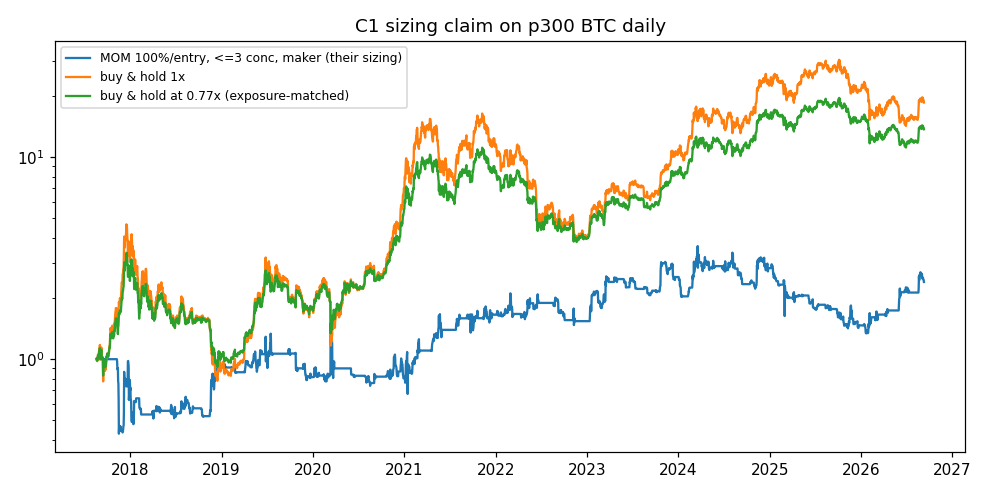

In [9]:
S = json.load(open('results/c1_summary.json', encoding='utf-8'))
print('parity:', S['parity']); print('p300 primary:', S['p300_btc']['primary']); print('era:', S['p300_btc']['era'])
print('bitstamp OOS 2012-17:', S['bitstamp']['oos']); print('eras:', S['bitstamp']['eras'])
print('ETH:', S['eth']); print('alts pooled:', S['alts'])
print('DSR:', {k: round(v['dsr'], 3) for k, v in S['dsr'].items() if v})
display(pd.read_csv('results/c1_per_year.csv'))
g = pd.read_csv('results/c1_grid.csv'); display(g.pivot_table(index=['z', 'W'], columns='H', values='t').round(2))
display(pd.read_csv('results/c1_alts.csv').sort_values('t', ascending=False).head(15))
for lab, s in S['sizing']['sims'].items():
    print(lab, 'B&H', s['buy_and_hold'])
    for k, v in s['runs'].items():
        print('  ', k, {kk: (round(vv, 3) if isinstance(vv, float) else vv) for kk, vv in v.items() if not isinstance(vv, dict)})
        for kk in ('bh_exposure_matched', 'strategy_curve_stats', 'boot_cagr_vs_bh_1x', 'boot_cagr_vs_bh_matched', 'boot_maxdd_vs_bh_1x', 'random_control'):
            if kk in v: print('      ', kk, v[kk])
display(Image('results/c1_equity.png'))


## C2 tables and figure

series: {'n': 7676, 'span': ['2019-09-10', '2026-09-11'], 'years': 7.0091324200913245, 'mean_8h_pct': 0.010577054715997916, 'share_positive': 0.8574778530484627, 'untimed_ann_pct': 11.58187491401772}
parity (last 1200 / 500 prints): {
 "expected": {
  "lag1": 0.75,
  "mean_8h_pct": 0.0031,
  "share_positive": 0.766,
  "ann_pct": 3.4,
  "quartiles_next_ann": [
   -2.2,
   2.5,
   5.5,
   7.7
  ]
 },
 "got": {
  "last_1200": {
   "lag1": 0.6659162493389492,
   "mean_8h_pct": 0.0033575941666666668,
   "share_positive": 0.7808333333333334,
   "ann_pct": 3.6765656125000006,
   "quartiles": [
    {
     "q": 1,
     "lo": -0.015177999999999999,
     "hi": 0.000407,
     "n": 299,
     "next_ann_pct": -1.0081397658862874
    },
    {
     "q": 2,
     "lo": 0.00041099999999999996,
     "hi": 0.0038120000000000003,
     "n": 299,
     "next_ann_pct": 3.0557018729096987
    },
    {
     "q": 3,
     "lo": 0.0038120000000000003,
     "hi": 0.0066890000000000005,
     "n": 299,
     "next_ann_pc

,year,n,lag1,lag2,lag3,mean_8h_pct,ann_pct,share_positive
0,2019,338,0.656,0.505,0.412,0.007,7.482,0.817
1,2020,1098,0.688,0.609,0.534,0.016,17.193,0.857
2,2021,1095,0.806,0.746,0.708,0.028,30.608,0.927
3,2022,1095,0.611,0.370,0.271,0.004,4.165,0.779
4,2023,1095,0.768,0.701,0.668,0.007,7.866,0.899
5,2024,1098,0.822,0.766,0.754,0.011,11.924,0.916
6,2025,1095,0.553,0.468,0.468,0.005,5.126,0.871
7,2026,762,0.692,0.609,0.583,0.003,2.756,0.726


,year,n,insample_q1,insample_q2,insample_q3,insample_q4,causal_q1,causal_n1,causal_q2,causal_n2,causal_q3,causal_n3,causal_q4,causal_n4
0,2019,338,-5.5,9.3,10.3,15.4,2.1,39,NaN,0,NaN,0,NaN,0
1,2020,1098,-5.1,11.8,13.0,48.9,0.3,344,11.0,460,11.0,1,47.0,293
2,2021,1095,6.8,10.5,24.4,80.1,8.9,625,NaN,0,28.0,175,78.1,295
3,2022,1095,-1.1,3.0,6.1,8.6,1.9,547,6.1,462,7.7,86,NaN,0
4,2023,1095,2.4,5.1,9.7,14.3,1.8,198,4.2,232,9.5,596,24.1,69
5,2024,1098,2.4,8.8,11.0,25.3,2.3,257,9.7,502,10.8,126,29.4,213
6,2025,1095,2.4,4.1,5.3,8.7,2.7,340,5.1,441,7.9,299,6.7,15
7,2026,761,-2.4,2.0,4.5,6.8,-1.4,260,2.6,176,5.1,181,7.6,144


,rule,share_held,round_trips,rt_per_year,gross_ann_pct,net_ann_pct
0,ALWAYS_ON,1.000,1,0.148,11.723,11.693
1,UPPER_HALF,0.338,486,72.149,8.373,-6.057
2,TOP_QUARTILE,0.140,235,34.887,6.223,-0.754
3,HYSTERESIS_p60_p40,0.406,190,28.206,9.480,3.838
4,UPPER_HALF_minhold21d,0.654,67,9.946,10.117,8.127
5,S078_live_rule,0.906,32,4.751,11.796,10.846


year,2020,2021,2022,2023,2024,2025,2026
rule,,,,,,,
ALWAYS_ON,17.19,30.61,4.16,7.87,11.92,5.13,2.61
HYSTERESIS_p60_p40,14.38,28.19,-1.66,-5.02,7.61,-7.73,-14.34
S078_live_rule,16.32,30.08,2.49,7.24,11.53,4.51,1.56
TOP_QUARTILE,2.44,10.36,0.00,-2.22,-1.75,-1.71,-17.54
UPPER_HALF,2.45,13.64,-5.91,-13.95,-1.30,-18.96,-24.10
UPPER_HALF_minhold21d,13.59,26.91,0.48,5.08,7.54,1.53,-0.63


era: {
 "ALWAYS_ON": {
  "pre_etf": {
   "n": 4451,
   "net_ann_pct": 14.853355184228267,
   "round_trips": 1
  },
  "post_etf": {
   "n": 2925,
   "net_ann_pct": 6.884440574358974,
   "round_trips": 0
  }
 },
 "UPPER_HALF": {
  "pre_etf": {
   "n": 4451,
   "net_ann_pct": -0.7992690620085384,
   "round_trips": 246
  },
  "post_etf": {
   "n": 2925,
   "net_ann_pct": -14.056859784615384,
   "round_trips": 240
  }
 },
 "TOP_QUARTILE": {
  "pre_etf": {
   "n": 4451,
   "net_ann_pct": 2.653709497865648,
   "round_trips": 123
  },
  "post_etf": {
   "n": 2925,
   "net_ann_pct": -5.940717164102564,
   "round_trips": 112
  }
 },
 "HYSTERESIS_p60_p40": {
  "pre_etf": {
   "n": 4451,
   "net_ann_pct": 8.966081410918896,
   "round_trips": 79
  },
  "post_etf": {
   "n": 2925,
   "net_ann_pct": -3.9644671538461544,
   "round_trips": 111
  }
 },
 "UPPER_HALF_minhold21d": {
  "pre_etf": {
   "n": 4451,
   "net_ann_pct": 11.467829952819592,
   "round_trips": 38
  },
  "post_etf": {
   "n": 2925,
  

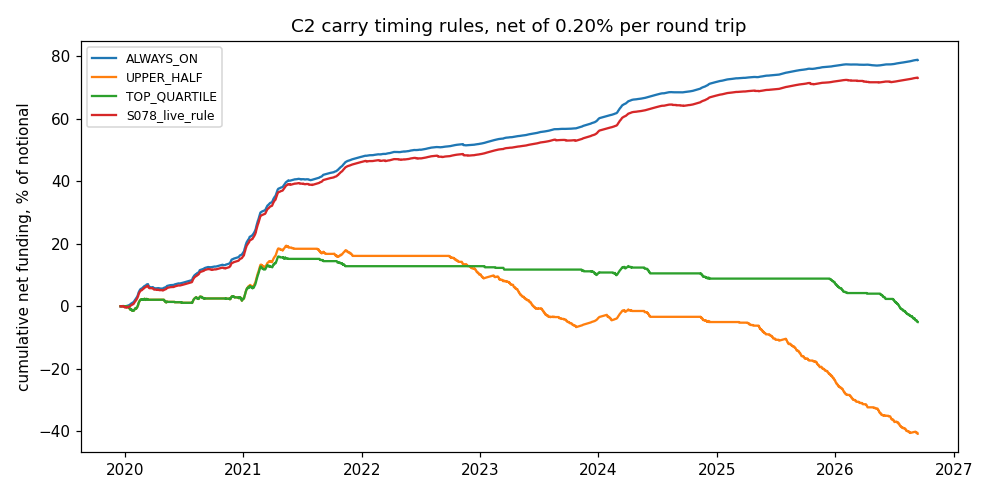

In [10]:
S = json.load(open('results/c2_summary.json', encoding='utf-8'))
print('series:', S['series']); print('parity (last 1200 / 500 prints):', json.dumps(S['parity'], indent=1)[:2500])
display(pd.DataFrame(S['autocorr_by_year']).round(3))
display(pd.read_csv('results/c2_quartiles.csv').round(1))
display(pd.DataFrame(S['rules']['table']).round(3))
p = pd.read_csv('results/c2_per_year.csv'); display(p.pivot_table(index='rule', columns='year', values='net_ann_pct').round(2))
print('era:', json.dumps(S['era'], indent=1)); print('bootstrap:', json.dumps(S['bootstrap_vs_always_on'], indent=1))
display(Image('results/c2_curves.png'))


## C3 tables and figure

parity: {'data': 'spot_BTCUSDT_5m_1177d.pkl', 'span': ['2023-06-22', '2026-09-11'], 'n_bars': 338976, 'got_2h': {'H': 24, 'hours': '2h', 'n': 1620, 'mean_bp': 4.79258084883779, 't': 2.906478357882651, 'tc': 2.158963340319387, 'g': 822, 'win': 56.04938271604938, 'capture': 6.695062568881532, 'n_long': 876, 'long_mean_bp': 2.465860899305881, 'n_short': 744, 'short_mean_bp': 7.532105950706006, 'net4.1': 0.6925808488377907, 'net5': -0.20741915116220966, 'net8': -3.2074191511622097}, 'expected': {'n': 1620, 'mean_bp': 4.8, 't': 2.91, 'tc': 2.16, 'capture': 6.7}, 'pass_': True, 'cell_2h_by_year': [{'year': 2023, 'n': 145, 'mean_bp': 3.24000549672461, 't': 0.7519265094728863, 'win': 54.48275862068965}, {'year': 2024, 'n': 356, 'mean_bp': 3.412386648614004, 't': 0.9213949191704441, 'win': 54.21348314606742}, {'year': 2025, 'n': 572, 'mean_bp': 7.90493038547085, 't': 2.917540334764925, 'win': 58.21678321678322}, {'year': 2026, 'n': 547, 'mean_bp': 2.8478068568487043, 't': 0.9644814389904729, 'w

,H,hours,n,mean_bp,t,tc,g,win,capture,n_long,long_mean_bp,n_short,short_mean_bp,net4.1,net5,net8
0,12,1h,1818,2.88,2.54,1.91,1187,53.08,5.70,980,1.72,838,4.24,-1.22,-2.12,-5.12
1,24,2h,1620,4.79,2.91,2.16,822,56.05,6.70,876,2.47,744,7.53,0.69,-0.21,-3.21
2,36,3h,1488,4.79,2.25,1.31,612,54.50,5.47,805,2.76,683,7.19,0.69,-0.21,-3.21
3,48,4h,1395,1.58,0.62,0.69,462,53.76,1.56,739,0.08,656,3.26,-2.52,-3.42,-6.42
4,72,6h,1224,2.15,0.68,0.52,283,53.10,1.74,663,-2.90,561,8.13,-1.95,-2.85,-5.85
5,96,8h,1104,1.50,0.39,-0.23,182,52.45,1.05,598,-2.37,506,6.08,-2.60,-3.50,-6.50
6,144,12h,946,4.99,0.93,-0.67,77,51.06,2.85,513,0.23,433,10.63,0.89,-0.01,-3.01
7,192,16h,813,-1.41,-0.22,-0.05,40,50.55,-0.70,432,-4.92,381,2.57,-5.51,-6.41,-9.41
8,288,1d,654,2.39,0.26,0.15,11,51.07,0.96,354,2.95,300,1.73,-1.71,-2.61,-5.61
9,432,1.5d,518,8.64,0.73,NaN,2,52.32,2.85,270,2.66,248,15.15,4.54,3.64,0.64


exact-resolution window: ['2025-06-08', '2026-06-07'] {'close': 0.0, 'volume': 3.7351142479866827e-16, 'volume_buy': 3.3474607739829614e-16}


,H,hours,n,mean_bp,t,tc,g,win,capture,n_long,long_mean_bp,n_short,short_mean_bp,net4.1,net5,net8
0,12,1h,758,2.90,1.77,1.83,468,52.24,6.09,424,2.88,334,2.93,-1.20,-2.10,-5.10
1,24,2h,665,4.29,1.56,1.10,297,55.34,6.36,368,3.11,297,5.75,0.19,-0.71,-3.71
2,36,3h,605,2.44,0.71,0.12,200,53.55,2.96,339,2.72,266,2.08,-1.66,-2.56,-5.56
3,48,4h,563,-2.12,-0.53,-0.45,140,52.93,-2.23,305,-1.76,258,-2.55,-6.22,-7.12,-10.12
4,72,6h,482,-0.20,-0.04,0.12,74,51.66,-0.17,271,-1.41,211,1.37,-4.30,-5.20,-8.20
5,96,8h,432,4.35,0.71,-0.22,37,53.47,3.22,237,5.16,195,3.36,0.25,-0.65,-3.65
6,144,12h,365,-1.48,-0.19,1.22,8,50.96,-0.90,208,-2.79,157,0.25,-5.58,-6.48,-9.48
7,192,16h,302,-7.56,-0.73,-0.47,3,47.35,-3.96,165,-8.09,137,-6.93,-11.66,-12.56,-15.56
8,288,1d,234,-3.81,-0.26,NaN,2,49.57,-1.63,128,-8.07,106,1.34,-7.91,-8.81,-11.81
9,432,1.5d,179,-4.48,-0.23,NaN,1,46.93,-1.56,95,0.99,84,-10.66,-8.58,-9.48,-12.48


,H,hours,n,mean_bp,t,tc,g,win,capture,n_long,long_mean_bp,n_short,short_mean_bp,net4.1,net5,net8
0,12,1h,758,2.90,1.77,1.83,468,52.24,6.09,424,2.88,334,2.93,-1.20,-2.10,-5.10
1,24,2h,665,4.29,1.56,1.10,297,55.34,6.36,368,3.11,297,5.75,0.19,-0.71,-3.71
2,36,3h,605,2.44,0.71,0.12,200,53.55,2.96,339,2.72,266,2.08,-1.66,-2.56,-5.56
3,48,4h,563,-2.12,-0.53,-0.45,140,52.93,-2.23,305,-1.76,258,-2.55,-6.22,-7.12,-10.12
4,72,6h,482,-0.20,-0.04,0.12,74,51.66,-0.17,271,-1.41,211,1.37,-4.30,-5.20,-8.20
5,96,8h,432,4.35,0.71,-0.22,37,53.47,3.22,237,5.16,195,3.36,0.25,-0.65,-3.65
6,144,12h,365,-1.48,-0.19,1.22,8,50.96,-0.90,208,-2.79,157,0.25,-5.58,-6.48,-9.48
7,192,16h,302,-7.56,-0.73,-0.47,3,47.35,-3.96,165,-8.09,137,-6.93,-11.66,-12.56,-15.56
8,288,1d,234,-3.81,-0.26,NaN,2,49.57,-1.63,128,-8.07,106,1.34,-7.91,-8.81,-11.81
9,432,1.5d,179,-4.48,-0.23,NaN,1,46.93,-1.56,95,0.99,84,-10.66,-8.58,-9.48,-12.48


...

,H,hours,n,mean_bp,t,tc,g,win,capture,n_long,long_mean_bp,n_short,short_mean_bp,net4.1,net5,net8
0,4,1h,378,1.98,0.63,0.27,347,55.82,2.94,207,1.21,171,2.90,-2.12,-3.02,-6.02
1,8,2h,366,4.17,0.90,0.66,329,54.64,4.38,201,2.82,165,5.83,0.07,-0.83,-3.83
2,12,3h,361,3.30,0.56,0.10,315,53.19,2.83,198,-1.84,163,9.54,-0.80,-1.70,-4.70
3,16,4h,354,7.35,1.09,0.87,304,51.41,5.46,197,7.56,157,7.09,3.25,2.35,-0.65
4,24,6h,349,0.22,0.03,0.52,270,51.58,0.14,193,-4.16,156,5.65,-3.88,-4.78,-7.78
5,32,8h,335,-7.91,-0.84,-0.24,253,54.33,-4.15,187,-16.86,148,3.39,-12.01,-12.91,-15.91
6,64,16h,315,4.80,0.37,0.37,182,52.70,1.78,172,-9.62,143,22.15,0.70,-0.20,-3.20
7,96,1d,299,20.52,1.22,0.55,141,55.85,6.22,163,8.82,136,34.53,16.42,15.52,12.52


eth_perp_15m ['2021-01-01', '2026-09-11']


,H,hours,n,mean_bp,t,tc,g,win,capture,n_long,long_mean_bp,n_short,short_mean_bp,net4.1,net5,net8
0,4,1h,272,-3.88,-0.75,-0.50,261,50.74,-4.62,162,-1.40,110,-7.52,-7.98,-8.88,-11.88
1,8,2h,269,-9.76,-1.36,-1.28,245,52.79,-8.23,159,-4.65,110,-17.15,-13.86,-14.76,-17.76
2,12,3h,266,-12.81,-1.43,-1.46,232,48.87,-8.82,157,-6.12,109,-22.46,-16.91,-17.81,-20.81
3,16,4h,263,-10.57,-1.05,-1.33,228,49.81,-6.30,156,-7.37,107,-15.23,-14.67,-15.57,-18.57
4,24,6h,258,-11.32,-0.95,-1.18,214,49.61,-5.51,152,-4.90,106,-20.51,-15.42,-16.32,-19.32
5,32,8h,251,-7.71,-0.53,-0.73,203,49.40,-3.25,149,3.94,102,-24.73,-11.81,-12.71,-15.71
6,64,16h,234,-17.14,-0.77,-0.78,158,47.86,-5.11,137,-4.19,97,-35.43,-21.24,-22.14,-25.14
7,96,1d,226,-4.05,-0.14,0.36,126,53.54,-0.98,129,12.00,97,-25.38,-8.15,-9.05,-12.05


primary spot 15m 2h: {'n': 1274, 'mean_bp': 0.11393760883112451, 't': 0.03977713578291354, 'tc': -0.48907878575211744, 'g': 1009, 'win': 52.90423861852433, 'capture': 0.1197865008543756, 'raw_mean_bp': 0.2363759289862706, 'n_long': 710, 'long_mean_bp': 1.7153073484704575, 'n_short': 564, 'short_mean_bp': -1.9019711059630722} {'pre_etf': {'n': 755, 'mean_bp': -0.7895636089383847, 't': -0.18342549528407018, 'win': 52.980132450331126}, 'post_etf': {'n': 519, 'mean_bp': 1.4282794574168287, 't': 0.44601279368060254, 'win': 52.79383429672448}} {'N1': 0.516, 'N348_study': 0.002}


,year,n,mean_bp,t,win
0,2019,67,-10.69,-1.16,53.73
1,2020,175,-9.23,-1.14,49.71
2,2021,281,-0.77,-0.10,52.31
3,2022,141,17.07,1.70,53.90
4,2023,88,-4.21,-0.38,59.09
5,2024,119,4.59,0.59,52.10
6,2025,226,2.17,0.49,54.87
7,2026,177,-2.16,-0.39,50.85


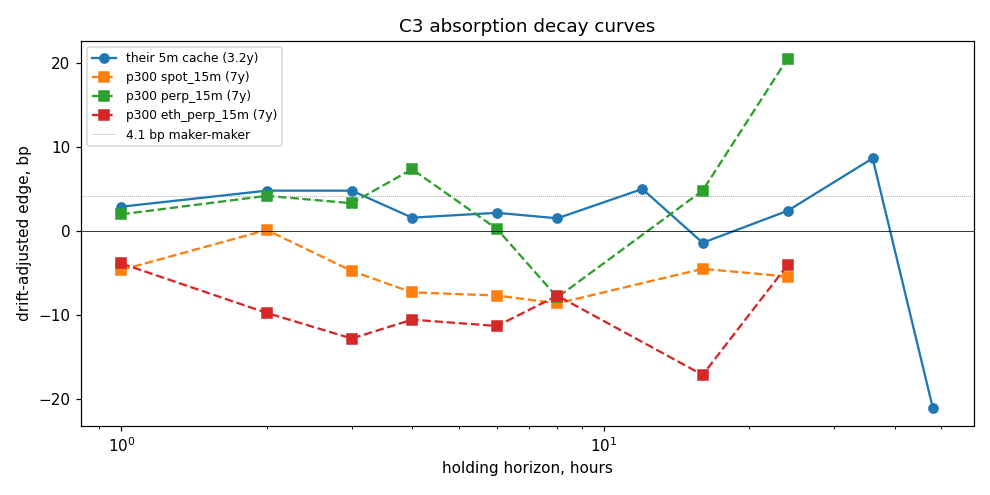

In [11]:
S = json.load(open('results/c3_summary.json', encoding='utf-8'))
print('parity:', {k: v for k, v in S['parity'].items() if k != 'decay_z1'})
display(pd.read_csv('results/c3_decay_their_cache_z1.csv').round(2))
print('exact-resolution window:', S['exact_resolution']['window'], S['exact_resolution']['max_rel_diff'])
display(pd.DataFrame(S['exact_resolution']['p300']).round(2)); display(pd.DataFrame(S['exact_resolution']['their_cache_same_window']).round(2))
for n in ('spot_15m', 'perp_15m', 'eth_perp_15m'):
    print(n, S['panels_15m'][n]['span']); display(pd.read_csv(f'results/c3_decay_{n}_z1.csv').round(2))
print('primary spot 15m 2h:', S['primary_spot15m_2h']['summary'], S['primary_spot15m_2h']['era'],
      {k: round(v['dsr'], 3) for k, v in S['primary_spot15m_2h']['dsr'].items()})
display(pd.read_csv('results/c3_per_year_spot15m.csv').round(2))
display(Image('results/c3_decay.png'))


## C4 tables

In [12]:
S = json.load(open('results/c4_summary.json', encoding='utf-8'))
print('parity:', json.dumps({k: v for k, v in S['parity'].items() if k in ('study', 'live', 'buy_and_hold', 'veto_inverts_under_live_fill')}, indent=1))
display(pd.read_csv('results/c4_phase_s005.csv').round(3))
display(pd.read_csv('results/c4_phase_p300.csv').round(2)); print('ranges:', S['phase_p300']['ranges'])
print('stop fill:', json.dumps(S['stop_fill_p300'], indent=1))
display(pd.read_csv('results/c4_shortleg.csv').round(2))
print('short leg:', json.dumps({k: v for k, v in S['short_leg'].items() if k != 'weight_sweep'}, indent=1))
display(pd.DataFrame(S['short_leg']['weight_sweep']).round(3))


parity:

 {
 "study": {
  "S003": {
   "got": [
    1.02,
    40.9,
    -58.8
   ],
   "expected": [
    1.02,
    40.9,
    -58.8
   ],
   "n_trades": 41,
   "pass_": true
  },
  "S005": {
   "got": [
    1.05,
    41.4,
    -41.2
   ],
   "expected": [
    1.05,
    41.4,
    -41.2
   ],
   "n_trades": 46,
   "pass_": true
  }
 },
 "live": {
  "S003": {
   "got": [
    1.08,
    43.6,
    -37.5
   ],
   "expected": [
    1.08,
    43.6,
    -37.5
   ],
   "n_trades": 41,
   "pass_": true
  },
  "S005": {
   "got": [
    1.01,
    39.4,
    -41.4
   ],
   "expected": [
    1.01,
    39.4,
    -41.4
   ],
   "n_trades": 46,
   "pass_": true
  }
 },
 "buy_and_hold": {
  "cagr": 0.42341277224890406,
  "sharpe": 0.8621231668988532,
  "maxdd": -0.8342934930460949
 },
 "veto_inverts_under_live_fill": true
}


,close_hour,sharpe,cagr,maxdd,n
0,0,1.052,0.418,-0.411,46
1,4,1.061,0.435,-0.458,40
2,8,1.046,0.466,-0.459,47
3,12,1.163,0.530,-0.461,39
4,16,1.066,0.436,-0.403,43
5,20,0.853,0.312,-0.537,46


,phase_hour,n,wr,pf,ret_pct,harness_maxdd,harness_mar,t_trade,daily_sharpe,daily_cagr,daily_maxdd,daily_mar
0,0,35,48.57,5.05,2536.64,-27.34,1.67,2.03,0.97,39.74,-50.93,0.78
1,1,33,48.48,4.47,1699.93,-27.34,1.44,1.91,0.82,31.29,-46.39,0.67
2,2,33,51.52,4.75,1844.09,-27.34,1.49,1.95,0.92,36.39,-47.56,0.77
3,3,36,50.00,5.40,3560.69,-27.34,1.88,2.15,1.08,46.66,-41.93,1.11
4,4,34,47.06,5.63,2853.43,-31.76,1.50,1.65,0.94,39.55,-54.79,0.72
5,5,35,37.14,4.37,1463.29,-35.02,1.06,1.47,0.77,28.50,-53.65,0.53
6,6,34,38.24,4.50,1452.81,-35.82,1.04,1.46,0.77,28.90,-53.75,0.54
7,7,37,45.95,4.80,2039.26,-27.43,1.54,1.55,0.86,34.26,-45.66,0.75
8,8,36,47.22,5.90,2828.20,-27.34,1.74,1.60,0.94,39.37,-46.70,0.84
9,9,36,50.00,4.15,1594.55,-27.34,1.41,1.87,0.82,31.48,-46.35,0.68


ranges: {'daily_sharpe': [0.7035705158868163, 1.0758483229744547], 'ret_pct': [885.8643117960569, 3560.687903436863], 'harness_maxdd': [-36.95470614810884, -19.17990000000003], 'harness_mar': [0.8288302644286429, 2.5445796206168025], 'n': [32, 40], 't_trade': [1.2847475930446783, 2.154183159302969]}
stop fill: {
 "live_fill": {
  "n_trades": 34,
  "t_trade": 2.0314338150824702,
  "cagr": 0.3974088849277335,
  "maxdd": -0.5093404945633119,
  "sharpe": 0.9672572484506252,
  "mar": 0.7802420761154205,
  "total": 17.3337007746898,
  "n_days": 3175,
  "time_in_market": 0.47811023622047244
 },
 "study_fill": {
  "n_trades": 34,
  "t_trade": 1.818033647836756,
  "cagr": 0.3131375170508439,
  "maxdd": -0.6140973889453314,
  "sharpe": 0.820679025226908,
  "mar": 0.5099150764810046,
  "total": 9.67658466839078,
  "n_days": 3175,
  "time_in_market": 0.47811023622047244
 },
 "buy_and_hold": {
  "cagr": 0.22230824577952557,
  "maxdd": -0.8118477145881698,
  "sharpe": 0.6386518180588917,
  "mar": 0.

,entry_dt,exit_dt,days,price_net_pct,funding_pct,total_pct,reason,still_open
0,2018-03-19,2018-04-24,36,-10.10,0.00,-10.10,SL,False
1,2018-10-23,2018-11-02,10,1.72,0.00,1.72,ADX<20,False
2,2018-11-18,2019-01-02,45,31.75,0.00,31.75,ADX<20,False
3,2019-09-25,2019-10-26,31,-10.10,0.56,-9.54,SL,False
4,2019-11-23,2019-12-28,35,-0.16,0.19,0.03,ADX<20,False
5,2021-04-22,2021-04-30,8,-10.10,0.34,-9.76,SL,False
6,2021-05-15,2021-09-05,113,-10.10,2.20,-7.90,SL,False
7,2022-04-27,2022-07-26,90,45.73,1.26,46.99,ADX<20,False
8,2022-09-06,2022-09-09,3,-10.10,0.04,-10.06,SL,False
9,2022-11-10,2022-12-21,41,4.31,0.26,4.57,ADX<20,False


short leg: {
 "n_short_closed": 19,
 "n_long_closed": 15,
 "short_mean_price_pct": 2.312633680234179,
 "short_mean_funding_pct": 0.3965569473684211,
 "short_mean_total_pct": 2.7091906276025997,
 "short_sum_total_pct": 51.474621924449394,
 "long_mean_pct": 31.506367099719238,
 "long_sum_pct": 472.5955064957886,
 "boot_short_total": {
  "mean": 2.7091906276025997,
  "n": 19,
  "block": 1,
  "n_iter": 5000,
  "ci": [
   -2.84085562118557,
   2.4795114350930536,
   8.980989912703459
  ],
  "p_gt_0": 0.7564
 },
 "boot_short_price": {
  "mean": 2.312633680234179,
  "n": 19,
  "block": 1,
  "n_iter": 5000,
  "ci": [
   -3.2052042535815217,
   2.0817745822712213,
   8.576615964309674
  ],
  "p_gt_0": 0.7198
 },
 "bear_years_2018_2022": {
  "n": 6,
  "mean_total_pct": 10.812151705664887,
  "mean_price_pct": 10.552557705664885
 },
 "eth_machine": {
  "n_short": 7,
  "short_mean_pct": 8.661090599651759,
  "short_sum_pct": 60.62763419756231,
  "n_long": 11,
  "long_mean_pct": 18.935072797434064,
 

,short_weight,cagr,maxdd,mar,sharpe,cagr_price_only,maxdd_price_only,mar_price_only
0,0.00,41.785,-31.001,1.348,1.245,41.785,-31.001,1.348
1,0.25,42.919,-31.952,1.343,1.242,42.609,-32.080,1.328
2,0.50,43.162,-36.002,1.199,1.179,42.543,-36.843,1.155
3,0.75,42.507,-42.779,0.994,1.086,41.583,-43.905,0.947
4,1.00,40.960,-49.615,0.826,0.987,39.741,-50.934,0.780


## C5 tables

In [13]:
S = json.load(open('results/c5_summary.json', encoding='utf-8'))
display(pd.read_csv('results/c5_cells.csv').round(2))
p = pd.read_csv('results/c5_rsi_plateau.csv'); display(p.pivot_table(index=['rsi_len', 'lvl', 'H'], columns='panel', values='t').round(2))
print(json.dumps(S['decision'], indent=1, default=str)[:4000])


,cell,H,panel,n,mean_bp,t,tc,g,win,capture,dsr_N7908,expected,share_assets_positive,n_assets
0,BBsqz20_fire_dn_short,4,bitstamp,142,240.86,4.50,4.92,64,64.79,29.97,0.77,"(142, 240.9, 4.77)",NaN,NaN
1,BBsqz20_fire_dn_short,4,p300_btc,81,167.49,2.39,3.19,42,60.49,25.23,NaN,NaN,NaN,NaN
2,BBsqz20_fire_dn_short,4,eth,75,146.74,1.70,1.01,32,64.00,18.19,NaN,NaN,NaN,NaN
3,BBsqz20_fire_dn_short,4,alts_pooled,1724,-21.95,-0.73,-0.27,112,55.22,NaN,NaN,NaN,0.52,64.0
4,BBsqz20_fire_dn_short,12,bitstamp,90,526.35,4.60,3.61,30,75.56,32.71,0.75,"(90, 526.4, 4.77)",NaN,NaN
5,BBsqz20_fire_dn_short,12,p300_btc,54,299.62,1.94,1.15,17,64.81,25.03,NaN,NaN,NaN,NaN
6,BBsqz20_fire_dn_short,12,eth,47,254.89,1.18,0.51,14,68.09,17.41,NaN,NaN,NaN,NaN
7,BBsqz20_fire_dn_short,12,alts_pooled,1110,41.85,0.83,0.28,105,57.03,NaN,NaN,NaN,0.58,64.0
8,BBsqz20_fire_dn_short,24,bitstamp,70,828.74,3.83,2.32,14,72.86,28.31,0.50,"(46, 1008.4, 4.19)",NaN,NaN
9,BBsqz20_fire_dn_short,24,p300_btc,45,397.01,1.50,2.80,8,60.00,22.30,NaN,NaN,NaN,NaN


panel           alts_pooled  bitstamp   eth
rsi_len lvl H                              
7       65  4          3.32      0.30 -0.37
            24         2.00      0.66  1.31
        70  4          3.73      1.51  0.17
            24         2.65      1.78  0.48
        75  4          3.84      3.26  0.20
            24         3.97      1.74  0.36
14      65  4          3.63      0.99  0.22
            24         4.55      1.91  1.28
        70  4          4.00      3.31  0.20
            24         4.06      2.88  0.43
        75  4          2.57      3.76  1.60
            24         3.12      2.23  3.48
21      65  4          2.90      1.65  0.89
            24         3.85      2.84  0.86
        70  4          3.55      2.60  0.36
            24         3.23      2.55  0.83
        75  4          2.44      1.48  0.69
            24         1.95      1.82  0.80

{
 "BBsqz20_fire_dn_short": {
  "bitstamp_best_H": 12,
  "bitstamp": {
   "cell": "BBsqz20_fire_dn_short",
   "H": 12,
   "panel": "bitstamp",
   "n": 90,
   "mean_bp": 526.3537227784516,
   "t": 4.597267377361654,
   "tc": 3.6056230889402094,
   "g": 30,
   "win": 75.55555555555556,
   "capture": 32.71153596422097,
   "dsr_N7908": 0.7535978774244041,
   "expected": "(90, 526.4, 4.77)",
   "share_assets_positive": null,
   "n_assets": null
  },
  "eth": {
   "cell": "BBsqz20_fire_dn_short",
   "H": 12,
   "panel": "eth",
   "n": 47,
   "mean_bp": 254.89355024143842,
   "t": 1.177352512996858,
   "tc": 0.5144922397683065,
   "g": 14,
   "win": 68.08510638297872,
   "capture": 17.41207867380056,
   "dsr_N7908": null,
   "expected": null,
   "share_assets_positive": null,
   "n_assets": null
  },
  "alts": {
   "cell": "BBsqz20_fire_dn_short",
   "H": 12,
   "panel": "alts_pooled",
   "n": 1110,
   "mean_bp": 41.84607599610768,
   "t": 0.8285521878357702,
   "tc": 0.27522269058897186,
   